In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

plt.style.use("ggplot")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/student-course-completion-prediction-dataset/Course_Completion_Prediction.csv


# DATA PREPROCESSING #

In [2]:
## importing the dataset

df = pd.read_csv("/kaggle/input/student-course-completion-prediction-dataset/Course_Completion_Prediction.csv")

df.head(3)

,Student_ID,Name,Gender,Age,Education_Level,Employment_Status,City,Device_Type,Internet_Connection_Quality,Course_ID,...,Enrollment_Date,Payment_Mode,Fee_Paid,Discount_Used,Payment_Amount,App_Usage_Percentage,Reminder_Emails_Clicked,Support_Tickets_Raised,Satisfaction_Rating,Completed
0,STU100000,Vihaan Patel,Male,19,Diploma,Student,Indore,Laptop,Medium,C102,...,01-06-2024,Scholarship,No,No,1740,49,3,4,3.5,Completed
1,STU100001,Arjun Nair,Female,17,Bachelor,Student,Delhi,Laptop,Low,C106,...,27-04-2025,Credit Card,Yes,No,6147,86,0,0,4.5,Not Completed
2,STU100002,Aditya Bhardwaj,Female,34,Master,Student,Chennai,Mobile,Medium,C101,...,20-01-2024,NetBanking,Yes,No,4280,85,1,0,5.0,Completed


In [3]:
## Filtering only a specific Python course

df = df[df["Course_Name"].str.contains("Data Analysis with Python", case=False, na=False)]

In [4]:
## Selecting the correct columns

req_columns = ["Student_ID",
           "Gender",
           "Age",
           "Education_Level",
           "Employment_Status",
           "Device_Type",
           "Login_Frequency",
           "Average_Session_Duration_Min",
           "Video_Completion_Rate",
           "Discussion_Participation",
           "Time_Spent_Hours",
           "Peer_Interaction_Score",
           "Assignments_Submitted",
           "Assignments_Missed",
            "Notifications_Checked",
            "Reminder_Emails_Clicked",
           "Progress_Percentage",
          "Rewatch_Count",
          "Completed"]

df = df[req_columns]

df.head(3)

,Student_ID,Gender,Age,Education_Level,Employment_Status,Device_Type,Login_Frequency,Average_Session_Duration_Min,Video_Completion_Rate,Discussion_Participation,Time_Spent_Hours,Peer_Interaction_Score,Assignments_Submitted,Assignments_Missed,Notifications_Checked,Reminder_Emails_Clicked,Progress_Percentage,Rewatch_Count,Completed
0,STU100000,Male,19,Diploma,Student,Laptop,3,30,55.0,2,0.5,4.3,8,1,6,3,70.8,0,Completed
5,STU100005,Female,21,Bachelor,Student,Mobile,7,30,85.9,1,11.8,6.2,7,3,9,5,75.3,5,Completed
14,STU100014,Male,19,Diploma,Employed,Mobile,5,23,73.8,3,0.5,10.0,2,8,4,1,40.9,3,Not Completed


In [5]:
## Renaming the columns

df = df.rename(
    columns={
        "Student_ID":"student_id",
        "Gender":"gender",
        "Age":"age",
        "Education_Level":"education_level",
        "Employment_Status":"employment_status",
        "Device_Type":"device_type",
        "Login_Frequency":"login_frequency",
        "Average_Session_Duration_Min":"avg_session_duration_min",
        "Video_Completion_Rate":"video_completion_rate",
        "Discussion_Participation":"discussion_participation",
        "Time_Spent_Hours":"time_spent_hours",
        "Peer_Interaction_Score":"peer_interaction_score",
        "Assignments_Submitted":"assignments_submitted",
        "Assignments_Missed":"assignments_missed",
        "Notifications_Checked":"notifications_checked",
        "Reminder_Emails_Clicked":"reminder_emails_clicked",
        "Progress_Percentage":"progress_percentage",
        "Rewatch_Count":"rewatch_count",
        "Completed":"completed"
    }
)

In [6]:
## add the numeric version of completed 

df["completed_num"] = df["completed"].map({
    "Completed":1,
    "Not Completed":0
})

In [7]:
## describing the column

df.describe()

,age,login_frequency,avg_session_duration_min,video_completion_rate,discussion_participation,time_spent_hours,peer_interaction_score,assignments_submitted,assignments_missed,notifications_checked,reminder_emails_clicked,progress_percentage,rewatch_count,completed_num
count,15465.000000,15465.000000,15465.000000,15465.000000,15465.000000,15465.000000,15465.000000,15465.000000,15465.000000,15465.000000,15465.000000,15465.000000,15465.000000,15465.000000
mean,25.678435,4.764048,33.865955,61.961326,2.318720,3.883718,6.281054,4.779631,5.121694,5.235823,2.330553,53.780569,2.333915,0.488393
std,5.595130,1.831777,10.280303,19.561466,1.598346,3.801144,1.983689,1.656107,1.686097,2.384000,1.596001,12.457452,1.570421,0.499881
min,17.000000,0.000000,5.000000,5.000000,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,0.000000,0.000000
25%,21.000000,3.000000,27.000000,48.300000,1.000000,0.500000,4.900000,4.000000,4.000000,4.000000,1.000000,45.300000,1.000000,0.000000
50%,26.000000,5.000000,34.000000,63.800000,2.000000,2.700000,6.300000,5.000000,5.000000,5.000000,2.000000,53.800000,2.000000,0.000000
75%,30.000000,6.000000,41.000000,77.200000,3.000000,6.200000,7.700000,6.000000,6.000000,7.000000,3.000000,62.400000,3.000000,1.000000
max,47.000000,14.000000,73.000000,99.700000,11.000000,23.800000,10.000000,10.000000,10.000000,17.000000,11.000000,96.500000,15.000000,1.000000


In [8]:
## scanning the columns

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15465 entries, 0 to 99994
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   student_id                15465 non-null  object 
 1   gender                    15465 non-null  object 
 2   age                       15465 non-null  int64  
 3   education_level           15465 non-null  object 
 4   employment_status         15465 non-null  object 
 5   device_type               15465 non-null  object 
 6   login_frequency           15465 non-null  int64  
 7   avg_session_duration_min  15465 non-null  int64  
 8   video_completion_rate     15465 non-null  float64
 9   discussion_participation  15465 non-null  int64  
 10  time_spent_hours          15465 non-null  float64
 11  peer_interaction_score    15465 non-null  float64
 12  assignments_submitted     15465 non-null  int64  
 13  assignments_missed        15465 non-null  int64  
 14  notificatio

# DATA ANALYSIS #

## OVERVIEW OF SAMPLE ##

### Breakdown of sample per gender ###

In [9]:
## Plotting the gender breakdown of the sample.

data_df = df.groupby("gender")["student_id"].count()
data_df = pd.DataFrame(data_df).reset_index()
data_df["percent"] = round((data_df["student_id"]/len(df)) * 100, 2)
data_df

,gender,student_id,percent
0,Female,7786,50.35
1,Male,7382,47.73
2,Other,297,1.92


### Plotting a pie chart for the gender groups ####

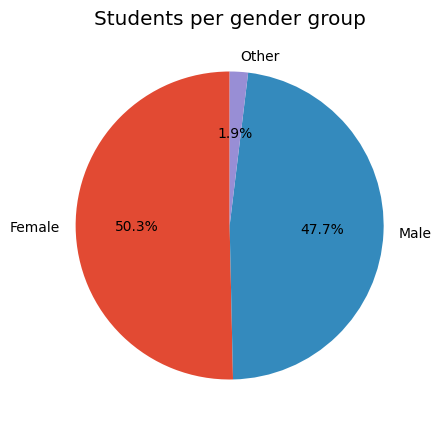

In [10]:
### Plotting the piechart ###

data_df = df.groupby("gender")["student_id"].count()
data_df = pd.DataFrame(data_df).reset_index()
data_df["percent"] = round((data_df["student_id"]/len(df)) * 100, 2)

viz_df_size = data_df["percent"]
viz_df_label = data_df["gender"]

## plotting the chart

plt.figure(figsize=(8,5))
plt.pie(viz_df_size, labels=viz_df_label, startangle=90, autopct="%1.1f%%")

## Annotating the chart

plt.title("Students per gender group")
plt.show()

### Finding completion rate per gender group ###

In [11]:
## plotting the pivot table

viz_df = pd.crosstab(df["gender"], df["completed"])
viz_df = viz_df.reset_index()
viz_df["completion_rate"] = round((viz_df["Completed"] / (viz_df["Completed"] + viz_df["Not Completed"])) * 100, 2)

viz_df

completed,gender,Completed,Not Completed,completion_rate
0,Female,3812,3974,48.96
1,Male,3592,3790,48.66
2,Other,149,148,50.17


### Performing Chi-Square tests on gender and completion

In [12]:
### plotting the crosstable

stat_df = pd.crosstab(df["gender"],df["completed"])
chi2, p_value, dof, expected = stats.chi2_contingency(stat_df)

## Printing the results
print(f"Chi-Statistic: {chi2}")
print(f'p-value: {p_value}')

print("The null hypothesis is rejected.")

Chi-Statistic: 0.35125617020018596
p-value: 0.8389299358667082
The null hypothesis is rejected.


### Overview of ages ###

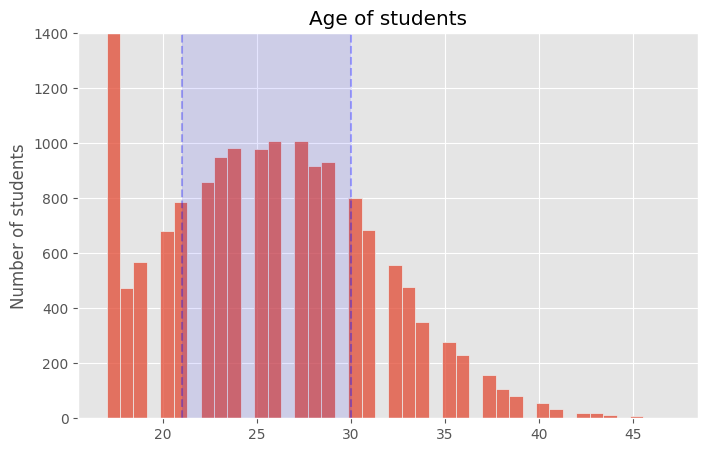

In [13]:
## plotting a histogram for the ages

viz_df = df["age"]

## plotting the chart

plt.figure(figsize=(8,5))
sns.histplot(viz_df)

## annotating the chart

plt.ylim(0,1400)
plt.title("Age of students")
plt.xlabel("")
plt.axvline(21, linestyle="--", alpha=0.3, color="blue")
plt.axvline(30, linestyle="--", alpha=0.3, color="blue")
plt.fill_between((21,30),1400,color="blue",alpha=0.1)
plt.ylabel("Number of students")

plt.show()

### Finding the relationship between age and completion / non completion ###

In [14]:
## Performing a logistc regression for age and completion

data_feature = df[["age"]]
data_target = df["completed"].map(
    {"Completed":1,"Not Completed":0}
)

### adding the constant

data_feature = sm.add_constant(data_feature)

model = sm.Logit(data_target, data_feature)

results = model.fit()

print(results.summary())
###print("Null hypothesis cannot be rejected - there is no statistically significant relationship between age and completion.")

Optimization terminated successfully.
         Current function value: 0.692811
         Iterations 3
                           Logit Regression Results                           
Dep. Variable:              completed   No. Observations:                15465
Model:                          Logit   Df Residuals:                    15463
Method:                           MLE   Df Model:                            1
Date:                Fri, 27 Feb 2026   Pseudo R-squ.:               9.615e-05
Time:                        06:45:51   Log-Likelihood:                -10714.
converged:                       True   LL-Null:                       -10715.
Covariance Type:            nonrobust   LLR p-value:                    0.1512
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0596      0.076      0.788      0.431      -0.089       0.208
age           -0.0041      0.

### Breakdown of sammple per device type ###

In [15]:
## Creating the crosstable for percentage

data_df = pd.crosstab(df["device_type"], df["completed"])
data_df = data_df.reset_index()
data_df["Total"] = data_df["Completed"] + data_df["Not Completed"]
data_df["Completion Rate"] = round((data_df["Completed"] / len(df)) * 100, 2)
data_df

print("Mobile users are twice as likely to complete the course more than laptop users.")

Mobile users are twice as likely to complete the course more than laptop users.


### Performing chi-square testing between device type and completion rate ###

In [16]:
### creating the cross tab ###

data_df = pd.crosstab(df["device_type"],df["completed"])

chi2, p_val, dof, contingency = stats.chi2_contingency(data_df)

print(chi2)
print(p_val)
print(f'Mobile users completed the course more frequently (29.47% vs 16.78%). However, a chi‑square test (χ² = 1.13, p = 0.567) indicates that this difference is not statistically significant. Further research with a larger sample size is recommended to determine whether device type truly influences completion rates.')

1.1334516812574809
0.5673800936754826
Mobile users completed the course more frequently (29.47% vs 16.78%). However, a chi‑square test (χ² = 1.13, p = 0.567) indicates that this difference is not statistically significant. Further research with a larger sample size is recommended to determine whether device type truly influences completion rates.


## Analyzing the relationship of engagement activities ##

### Basic overview of the engagement activities ###

In [17]:
## plotting the columns for engagemnet activities

data_df = df[["login_frequency","notifications_checked","reminder_emails_clicked","completed_num"]]

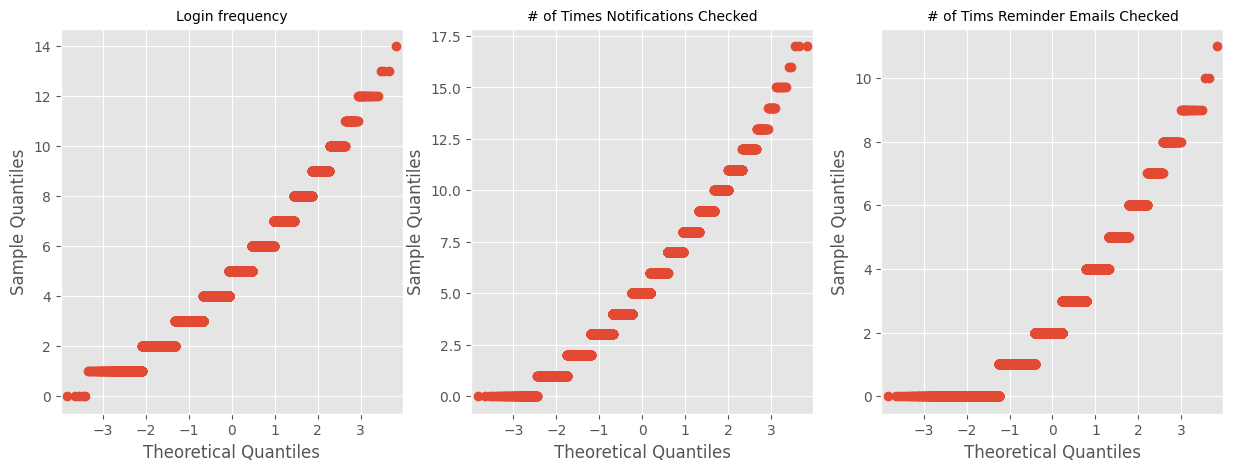

In [18]:
## plotting qqplots

data_login = df["login_frequency"]
data_notif = df["notifications_checked"]
data_email = df["reminder_emails_clicked"]

## plotting the qqplots

fig, axes = plt.subplots(1,3, figsize=(15,5))

sm.qqplot(data_login, ax=axes[0])
axes[0].set_title("Login frequency", size=10)

sm.qqplot(data_notif, ax=axes[1])
axes[1].set_title("# of Times Notifications Checked", size=10)

sm.qqplot(data_email, ax=axes[2])
axes[2].set_title("# of Tims Reminder Emails Checked", size=10)

plt.show()

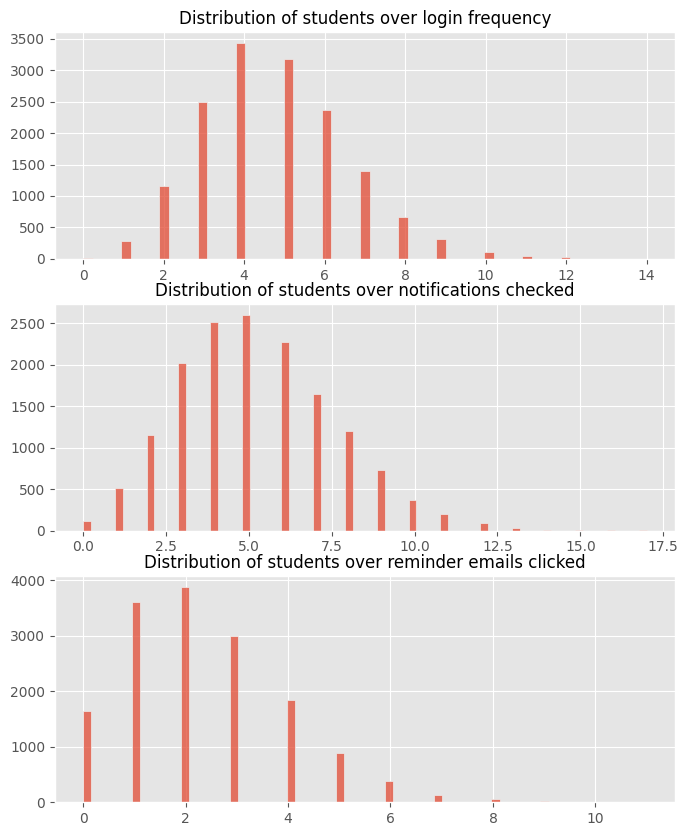

In [19]:
### plotting the histograms

fig, axes = plt.subplots(3,1, figsize=(8,10))

data_login = df["login_frequency"]
data_notif = df["notifications_checked"]
data_email = df["reminder_emails_clicked"]

## plotting the first graph

sns.histplot(data_login, ax=axes[0])
axes[0].set_title("Distribution of students over login frequency", size=12)
axes[0].set_xlabel("")
axes[0].set_ylabel("")

## plotting the second graph

sns.histplot(data_notif, ax=axes[1])
axes[1].set_title("Distribution of students over notifications checked", size=12)
axes[1].set_xlabel("")
axes[1].set_ylabel("")

## plotting the third graph

sns.histplot(data_email, ax=axes[2])
axes[2].set_title("Distribution of students over reminder emails clicked", size=12)
axes[2].set_xlabel("")
axes[2].set_ylabel("")


plt.show()


### Performing Logistic Regression: Login Frequency vs Completion Status ###

In [20]:
## performing the logistic regression ##

df_feature = df[["login_frequency"]]
df_target = df["completed_num"]

## adding the constant

df_feature = sm.add_constant(df_feature)

model = sm.Logit(df_target, df_feature)

results = model.fit()

print(results.summary())

Optimization terminated successfully.
         Current function value: 0.691845
         Iterations 3
                           Logit Regression Results                           
Dep. Variable:          completed_num   No. Observations:                15465
Model:                          Logit   Df Residuals:                    15463
Method:                           MLE   Df Model:                            1
Date:                Fri, 27 Feb 2026   Pseudo R-squ.:                0.001490
Time:                        06:45:52   Log-Likelihood:                -10699.
converged:                       True   LL-Null:                       -10715.
Covariance Type:            nonrobust   LLR p-value:                 1.598e-08
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.2833      0.045     -6.300      0.000      -0.371      -0.195
login_frequenc

#### RESULTS OF LOGISTIC REGRESSION ####

pvalue is < 0.001, the null hypothesis is rejected
the coefficient is at 0.0497.

### Performing Logistic Regression: Notifications Checked vs Completion Status

In [21]:
### performing the logistic regression

df_feature = df[["notifications_checked"]]
df_target = df["completed_num"]

## usiing the model

df_feature = sm.add_constant(df_feature)
model = sm.Logit(df_target, df_feature)
results = model.fit()

## printing the results

print(results.summary())

Optimization terminated successfully.
         Current function value: 0.692273
         Iterations 3
                           Logit Regression Results                           
Dep. Variable:          completed_num   No. Observations:                15465
Model:                          Logit   Df Residuals:                    15463
Method:                           MLE   Df Model:                            1
Date:                Fri, 27 Feb 2026   Pseudo R-squ.:               0.0008729
Time:                        06:45:52   Log-Likelihood:                -10706.
converged:                       True   LL-Null:                       -10715.
Covariance Type:            nonrobust   LLR p-value:                 1.524e-05
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -0.1994      0.039     -5.127      0.000      -0.276      -0.

### Performing Logistic Regression: Reminder Emails vs Completion Status ###

In [22]:
## #setting the axes

df_feature = df[["reminder_emails_clicked"]]
df_target = df["completed_num"]

## creating the model

df_feature = sm.add_constant(df_feature)
model = sm.Logit(df_target, df_feature)
results = model.fit()

## print the results
print(results.summary())

Optimization terminated successfully.
         Current function value: 0.692532
         Iterations 3
                           Logit Regression Results                           
Dep. Variable:          completed_num   No. Observations:                15465
Model:                          Logit   Df Residuals:                    15463
Method:                           MLE   Df Model:                            1
Date:                Fri, 27 Feb 2026   Pseudo R-squ.:               0.0004988
Time:                        06:45:52   Log-Likelihood:                -10710.
converged:                       True   LL-Null:                       -10715.
Covariance Type:            nonrobust   LLR p-value:                  0.001078
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -0.1233      0.028     -4.326      0.000      -0.179   

### STATISTICAL ANALYSIS 

Results show that interest variables are statistically significant with completing the course. In fact, for every email, notification, and login interacted with, the odds of completing the course increases by 3%.

## ANALYSIS OF INTERACTION ACTIVITIES ##

Interaction activities are variables that indicate a student's interest in interacting with other students of the course.

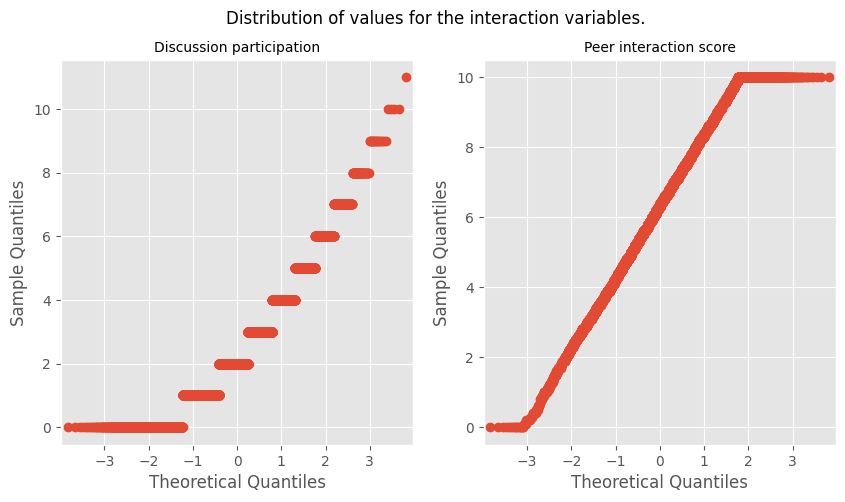

In [23]:
### Plotting hte qq plots for the interaction variables

fig, axes = plt.subplots(1, 2, figsize=(10,5))

## plotting the axes

sm.qqplot(df["discussion_participation"], ax=axes[0])
axes[0].set_title("Discussion participation", size=10)

sm.qqplot(df["peer_interaction_score"], ax=axes[1])
axes[1].set_title("Peer interaction score", size=10)


plt.suptitle("Distribution of values for the interaction variables.")
plt.show()

### Performing Logistic Regression: Discussion participation score vs Completion Status

Discussion participation is significantly related to the probability of someone completing the course. The coefficient is 0.0303, the intercept at -0.1166, and the p-value is 0.003. 

The odds ratio is p = e ^ 0.0303 --> 1.03. Every increase in the discussion participation score increases the probability of completing by 3%.

In [24]:
### plotting the axes ###

df_feature = df[["discussion_participation"]]
df_target = df["completed_num"]

### creating the model

df_feature = sm.add_constant(df_feature)
model = sm.Logit(df_target, df_feature)
results = model.fit()

### printing the results
print(results.summary())

Optimization terminated successfully.
         Current function value: 0.692585
         Iterations 3
                           Logit Regression Results                           
Dep. Variable:          completed_num   No. Observations:                15465
Model:                          Logit   Df Residuals:                    15463
Method:                           MLE   Df Model:                            1
Date:                Fri, 27 Feb 2026   Pseudo R-squ.:               0.0004218
Time:                        06:45:53   Log-Likelihood:                -10711.
converged:                       True   LL-Null:                       -10715.
Covariance Type:            nonrobust   LLR p-value:                  0.002642
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -0.1166      0.028     -4.112      0.000      -0.172

### Performing Logistic Regression: Peer interaction score vs Completion Status

Students interacting with their peers is significantly related to the probability of someone completing the course. The coefficient is 0.0234, the intercept at -0.1937, and the p-value is 0.004. 

The odds ratio is p = e ^ 0.0234 --> 1.023. Every increase in the discussion participation score increases the probability of completing by 2%.

In [25]:
### performing the logistic regression

### plotting the axes

df_feature = df[["peer_interaction_score"]]
df_target = df["completed_num"]

### creating the model

df_feature = sm.add_constant(df_feature)
model = sm.Logit(df_target, df_feature)
results = model.fit()

### printing the results

print(results.summary())

Optimization terminated successfully.
         Current function value: 0.692608
         Iterations 3
                           Logit Regression Results                           
Dep. Variable:          completed_num   No. Observations:                15465
Model:                          Logit   Df Residuals:                    15463
Method:                           MLE   Df Model:                            1
Date:                Fri, 27 Feb 2026   Pseudo R-squ.:               0.0003893
Time:                        06:45:53   Log-Likelihood:                -10711.
converged:                       True   LL-Null:                       -10715.
Covariance Type:            nonrobust   LLR p-value:                  0.003873
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0.1937      0.053     -3.621      0.000      -0.298      